## Task 1

In [1]:
import librosa
import numpy as np

def make_stereo(audio_paths, mix_matrix, sr=None, mono=False):
  audios = []
  rates = []

  for path in audio_paths:
    audio, rate = librosa.load(path, sr=sr, mono=True)
    audios.append(audio)
    rates.append(rate)
  
  # Check sample rates
  if sr is None and not all(r == rates[0] for r in rates):
    raise ValueError("Sample rates must match. Set sr to fixed value if needed.")

  # Pad or trim to same length
  max_len = max(len(a) for a in audios)
  audios_equal = [np.pad(a, (0, max_len - len(a)), 'constant') if len(a) < max_len else a[:max_len] for a in audios]
  
  stacked_audio = np.stack(audios_equal, axis=-1)  # shape (num_samples, num_channels)

  # Check mix_matrix shape
  num_channels = len(audio_paths)
  if mix_matrix.shape[1] != num_channels:
    raise ValueError(f"mix_matrix should have {num_channels} columns.")

  # Apply mixing: mixes = stacked_audio @ mix_matrix.T
  mixes = np.dot(stacked_audio, mix_matrix.T)  # shape (num_samples, num_mixes)

  # Conver to mono if True
  if mono:
    mixes = mixes.mean(axis=1)

  return mixes.T, rates[0] if sr is None else sr

In [2]:
audio_paths = [
  './Exercises Dataset/Exer1/spk1.wav',
  './Exercises Dataset/Exer1/spk2.wav',
  './Exercises Dataset/Exer1/spk3.wav',
  './Exercises Dataset/Exer1/spk4.wav'
]


mix_matrix = np.array([
  [0.8, 0.1, 0.05, 0.05],   # 80% of frist + 10% of second + 10% of third
  [0.2, 0.7, 0.05, 0.05],   # 20% of first + 70% of second + 10% of third
  [0.1, 0.1, 0.7, 0.1],    # 10% of first + 20% of second + 70% of third
  [0.05, 0.05, 0.1, 0.8]
])

sr = 8000

mixture_4, _ = make_stereo(audio_paths, mix_matrix, sr=8000)

d:\tools\Anaconda\envs\audio\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import IPython.display as ipd

ipd.Audio(data=mixture_4, rate=sr)

In [3]:
from sklearn.decomposition import FastICA

# Initialize ICA with 4 components
ica4 = FastICA(n_components=4)

# Fit ICA and transform the data
ica4_fitted = ica4.fit_transform(mixture_4.T)  # Shape: (n_samples, 4)

# Transpose back to (4, samples) for saving
separated_sources_ICA = ica4_fitted.T  # Shape: (4, n_samples)

In [6]:
for i in range(4):
  print(f"Source {i+1}")
  ipd.display(ipd.Audio(data=separated_sources_ICA[i], rate=sr))

Source 1


Source 2


Source 3


Source 4


d:\tools\Anaconda\envs\audio\lib\site-packages\matplotlib\axes\_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


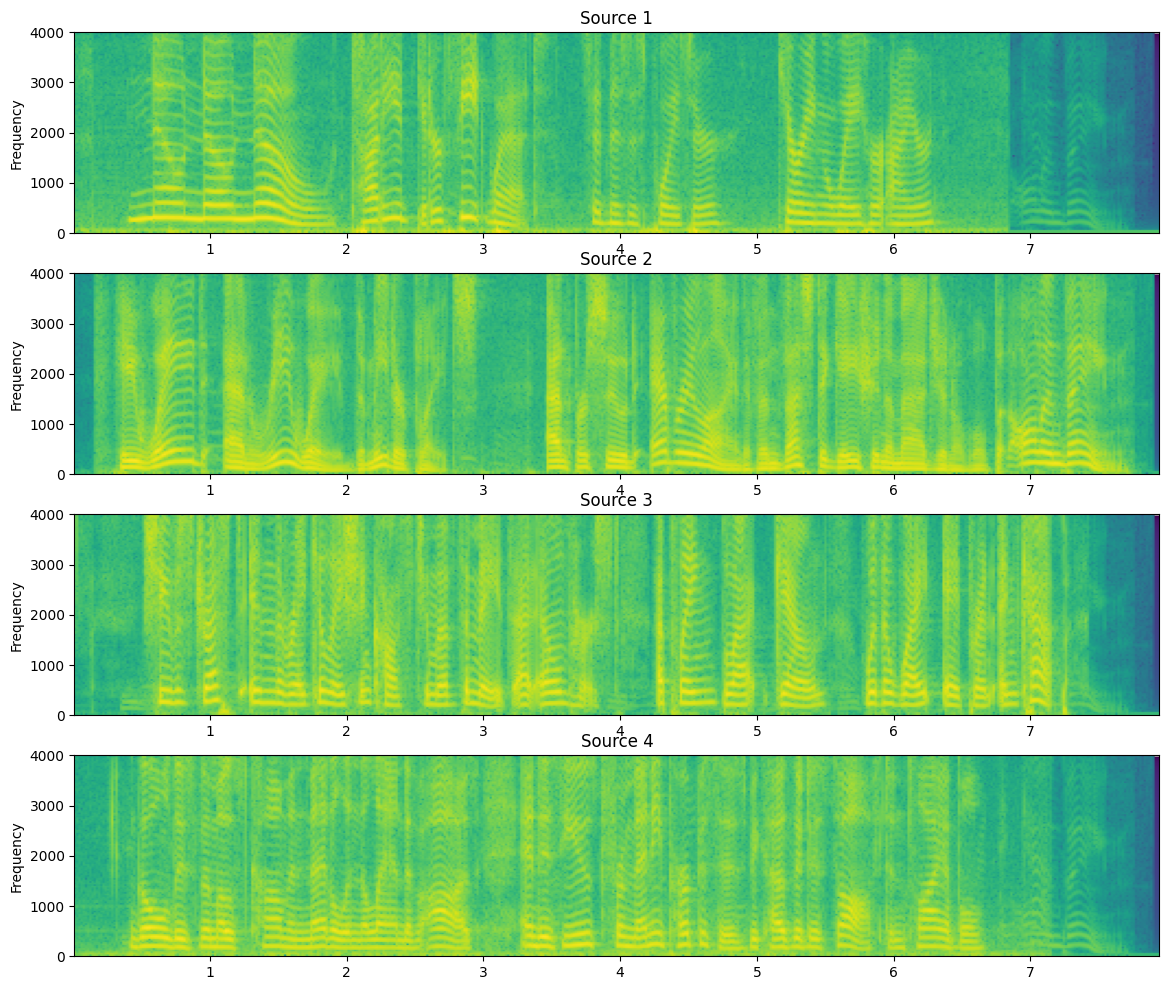

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
for i in range(4):
  plt.subplot(4, 1, i+1)
  plt.title(f"Source {i+1}")
  plt.specgram(separated_sources_ICA[i], Fs=8000)
  plt.ylabel("Frequency")

# plt.tight_layout()
plt.show()

## Task 2

## Task 3

## Task 4

In [ ]:
import sounddevice as sd
from scipy.io.wavfile import write

fs = 16000
seconds = 5
audio_name = "myvoice.wav"

print("Recording...")
audio = sd.rec(int(seconds * fs), samplerate=fs, channels=1, dtype='float32')
sd.wait()
print("Recording complete.")

write(audio_name, fs, audio)
print(f"Saved as {audio_name}")

In [ ]:
import numpy as np

def make_stereo(audio_paths, mix_matrix, sr=None, mono=False):
  audios = []
  rates = []

  for path in audio_paths:
    audio, rate = librosa.load(path, sr=sr, mono=True)
    audios.append(audio)
    rates.append(rate)
  
  # Check sample rates
  if sr is None and not all(r == rates[0] for r in rates):
    raise ValueError("Sample rates must match. Set sr to fixed value if needed.")

  # Pad or trim to same length
  max_len = max(len(a) for a in audios)
  audios_equal = [np.pad(a, (0, max_len - len(a)), 'constant') if len(a) < max_len else a[:max_len] for a in audios]
  
  stacked_audio = np.stack(audios_equal, axis=-1)  # shape (num_samples, num_channels)

  # Check mix_matrix shape
  num_channels = len(audio_paths)
  if mix_matrix.shape[1] != num_channels:
    raise ValueError(f"mix_matrix should have {num_channels} columns.")

  # Apply mixing: mixes = stacked_audio @ mix_matrix.T
  mixes = np.dot(stacked_audio, mix_matrix.T)  # shape (num_samples, num_mixes)

  # Conver to mono if True
  if mono:
    mixes = mixes.mean(axis=1)

  return mixes.T, rates[0] if sr is None else sr

In [ ]:
audio_paths = [
  "myvoice.wav",
  "./Exercises Dataset/Exer4/noise_A.wav"
]

mix_matrix = np.array([
  [0.6, 0.4],
  [0.4, 0.6]
])

sr = 16000

mixture_X, _ = make_stereo(audio_paths, mix_matrix, sr, True)

ipd.Audio(data=mixture_X, rate=sr)

In [ ]:
import torch
from asteroid.models import BaseModel

_original_torch_load = torch.load

def torch_load(*args, **kwargs):
  kwargs["weights_only"] = False
  return _original_torch_load(*args, **kwargs)

torch.load = torch_load

dprnn = BaseModel.from_pretrained("mpariente/DPRNNTasNet-ks2_WHAM_sepclean")